<a href="https://colab.research.google.com/github/Vaishnavi200527/RollNo_39_MLDL_Lab/blob/main/EXP9_MLDLipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 1: Import Libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing import sequence
import matplotlib.pyplot as plt

In [2]:
# Step 2: Load Dataset
max_features = 10000  # Vocabulary size
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Step 3: Padding Sequences
maxlen = 200
X_train = sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = sequence.pad_sequences(X_test, maxlen=maxlen)

In [8]:
# Step 4: Build LSTM Model
model = Sequential()

model.add(Embedding(max_features, 128))
model.add(LSTM(64))
model.add(Dense(1, activation='sigmoid'))

In [9]:
# Step 5: Compile Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [10]:
# Step 6: Train Model
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 107ms/step - accuracy: 0.8049 - loss: 0.4266 - val_accuracy: 0.8481 - val_loss: 0.3553
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.8904 - loss: 0.2735 - val_accuracy: 0.8734 - val_loss: 0.3188
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 77s 99ms/step - accuracy: 0.9039 - loss: 0.2428 - val_accuracy: 0.7768 - val_loss: 0.4659
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.8666 - loss: 0.3114 - val_accuracy: 0.8655 - val_loss: 0.3439
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 105ms/step - accuracy: 0.9461 - loss: 0.1460 - val_accuracy: 0.8626 - val_loss: 0.4097


In [11]:
# Step 7: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8626 - loss: 0.4097
Accuracy: 0.8626400232315063


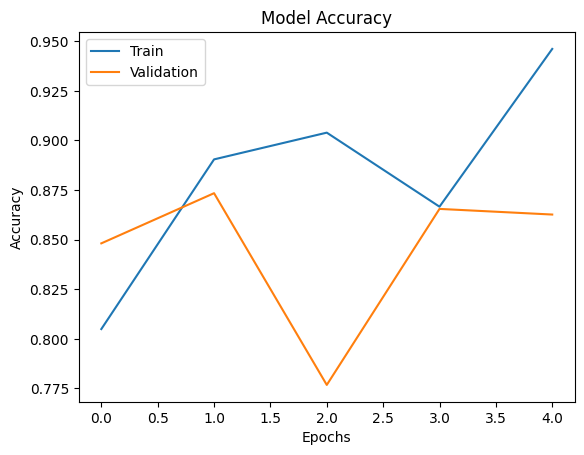

In [12]:
# Step 8: Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

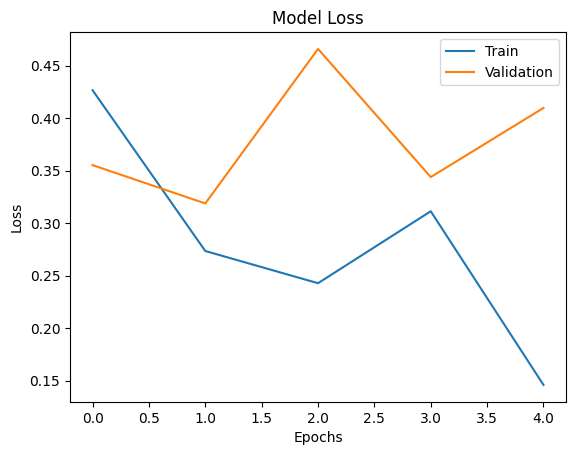

In [13]:
# Step 9: Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()